# Charger les données nettoyées

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/clean_telco_churn.csv")

df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


# Fonctions utiles pour l'EDA

In [2]:
def churn_rate_table(data, column):
    result = (
        data.groupby(column)["Churn"]
        .agg(["count", "mean"])
        .rename(columns={"count": "n_clients", "mean": "churn_rate"})
        .sort_values("churn_rate", ascending=False)
    )
    return result

In [3]:
def plot_churn_rate(data, column, figsize=(8, 4), rotation=0):
    summary = churn_rate_table(data, column)

    plt.figure(figsize=figsize)
    plt.bar(summary.index.astype(str), summary["churn_rate"])
    plt.title(f"Taux de churn par {column}")
    plt.xlabel(column)
    plt.ylabel("Taux de churn")
    plt.xticks(rotation=rotation)
    plt.ylim(0, 1)
    plt.show()

    return summary

# Vue globale du churn

In [4]:
churn_global = df["Churn"].mean()
print(f"Taux de churn global : {churn_global:.2%}")

Taux de churn global : 26.58%


Nous observons dans un premier temps que le churn global se trouve à 26.58%, ce qui veut dire que plus d'un client sur quatre s'en va.

# Analyse par type de contrat

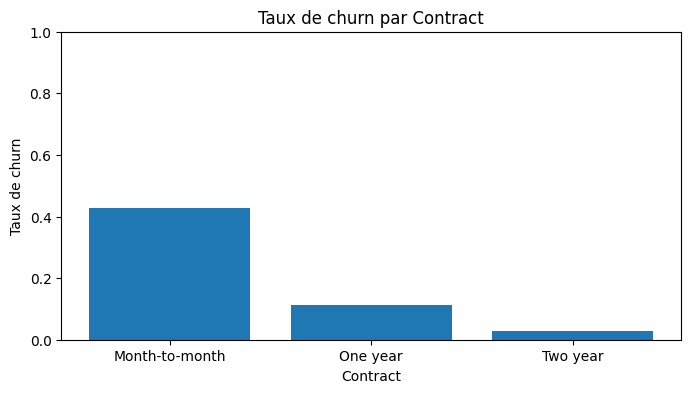

,n_clients,churn_rate
Contract,,
Month-to-month,3875,0.427097
One year,1472,0.112772
Two year,1685,0.028487


In [5]:
contract_summary = plot_churn_rate(df, "Contract")
contract_summary

On remarque sur ce graph et cette table que les clients engagés sur des contrat long ont plus tendance à rester, contrairement aux clients mensuels qui sont plus à même de partir. Ceci fait donc des clients mensuels une cible à prioriser.

# Analyse par ancienneté

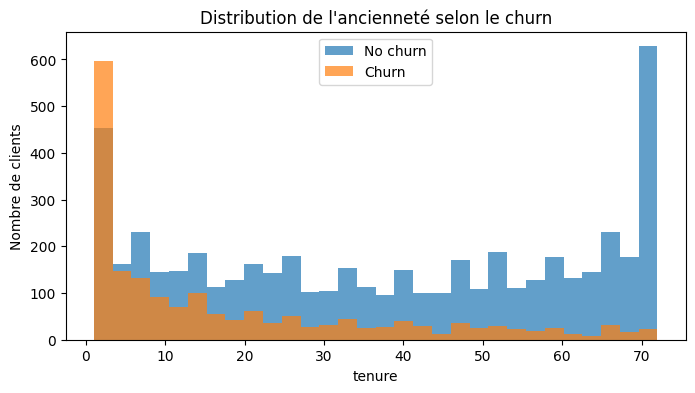

In [6]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == 0]["tenure"], bins=30, alpha=0.7, label="No churn")
plt.hist(df[df["Churn"] == 1]["tenure"], bins=30, alpha=0.7, label="Churn")
plt.title("Distribution de l'ancienneté selon le churn")
plt.xlabel("tenure")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

C:\Users\QuentinGENSE\AppData\Local\Temp\ipykernel_25456\1637542074.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["Churn"]


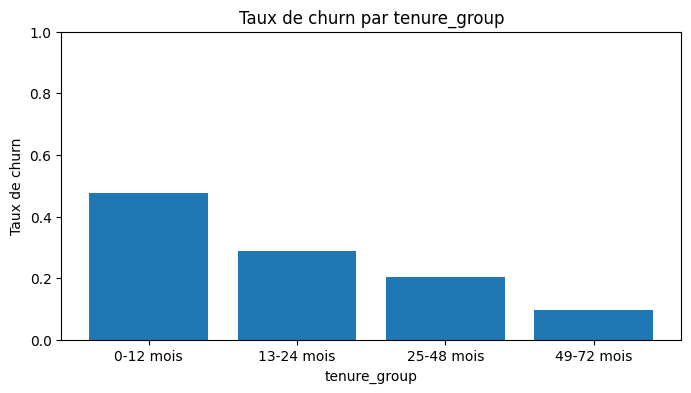

,n_clients,churn_rate
tenure_group,,
0-12 mois,2175,0.476782
13-24 mois,1024,0.287109
25-48 mois,1594,0.203890
49-72 mois,2239,0.095132


In [8]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=["0-12 mois", "13-24 mois", "25-48 mois", "49-72 mois"],
    include_lowest=True
)

tenure_summary = plot_churn_rate(df, "tenure_group", rotation=0)
tenure_summary

On observe sur ces graph que les clients ont moins tendance à partir si cela fait longtemps qu'ils sont en relation avec nous

# Analyse par niveau de facturation mensuelle

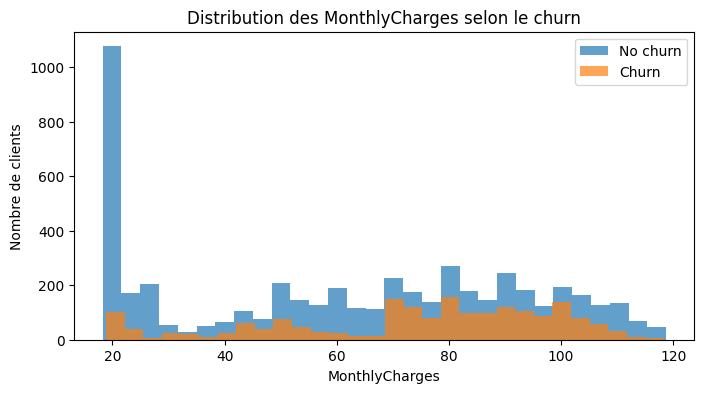

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df[df["Churn"] == 0]["MonthlyCharges"], bins=30, alpha=0.7, label="No churn")
plt.hist(df[df["Churn"] == 1]["MonthlyCharges"], bins=30, alpha=0.7, label="Churn")
plt.title("Distribution des MonthlyCharges selon le churn")
plt.xlabel("MonthlyCharges")
plt.ylabel("Nombre de clients")
plt.legend()
plt.show()

C:\Users\QuentinGENSE\AppData\Local\Temp\ipykernel_25456\1637542074.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  data.groupby(column)["Churn"]


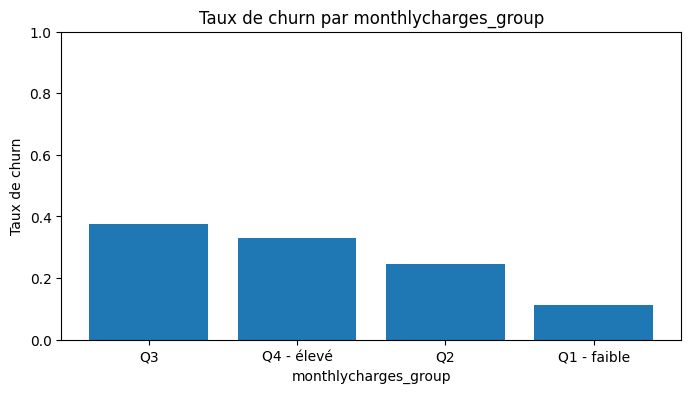

,n_clients,churn_rate
monthlycharges_group,,
Q3,1755,0.375499
Q4 - élevé,1758,0.328783
Q2,1761,0.245883
Q1 - faible,1758,0.113197


In [10]:
df["monthlycharges_group"] = pd.qcut(
    df["MonthlyCharges"],
    q=4,
    labels=["Q1 - faible", "Q2", "Q3", "Q4 - élevé"]
)

charges_summary = plot_churn_rate(df, "monthlycharges_group", rotation=0)
charges_summary

Les clients avec des mensualités plus élevées ont plus tendance à churner, ce qui peut signifier qu'il existe une sensibilité au prix ou un décalage entre la valeur perçue et les coûts.

# Analyse par mode de paiement

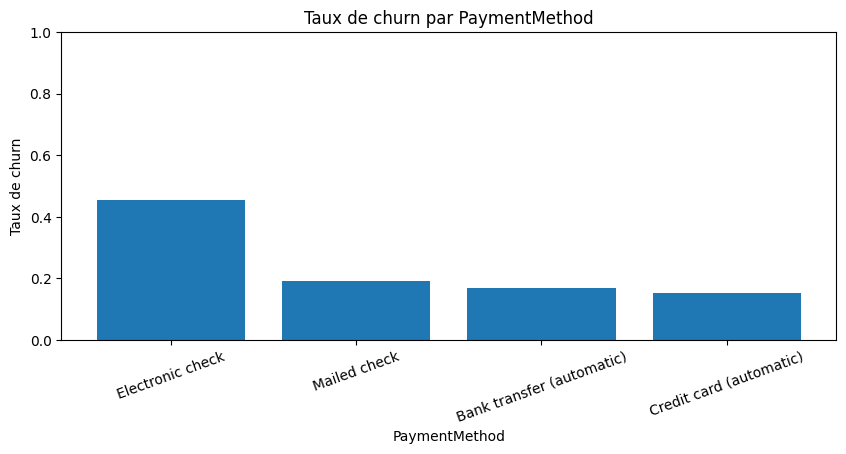

,n_clients,churn_rate
PaymentMethod,,
Electronic check,2365,0.452854
Mailed check,1604,0.192020
Bank transfer (automatic),1542,0.167315
Credit card (automatic),1521,0.152531


In [11]:
payment_summary = plot_churn_rate(df, "PaymentMethod", figsize=(10, 4), rotation=20)
payment_summary

Les clients effectuant un payement electronique ont plus tendance à partir. Ceci ne refléte en rien d'une cause du churn, mais plutôt d'un signal comportemental à prendre en compte lors de la segmentation.

# Analyse des services additionnels

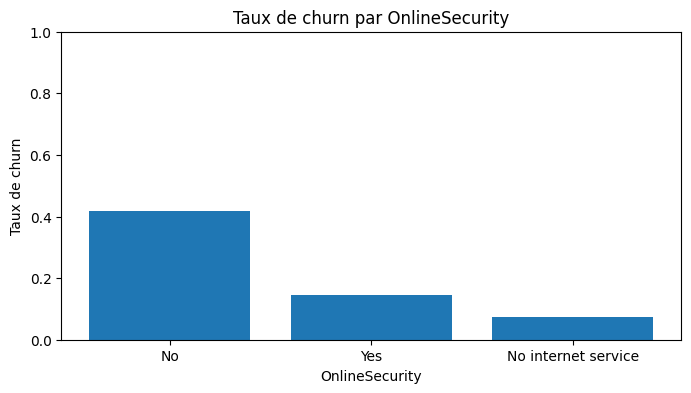

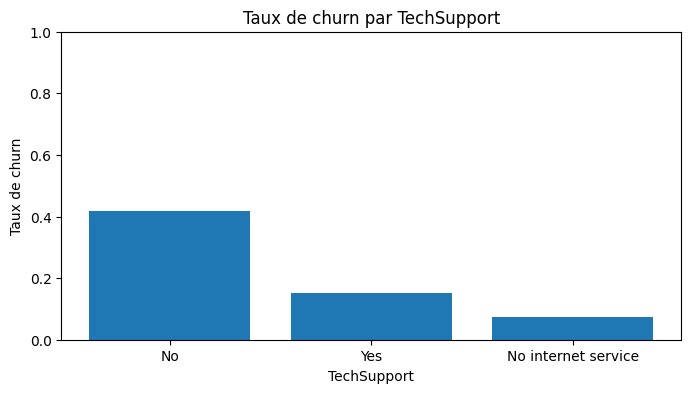

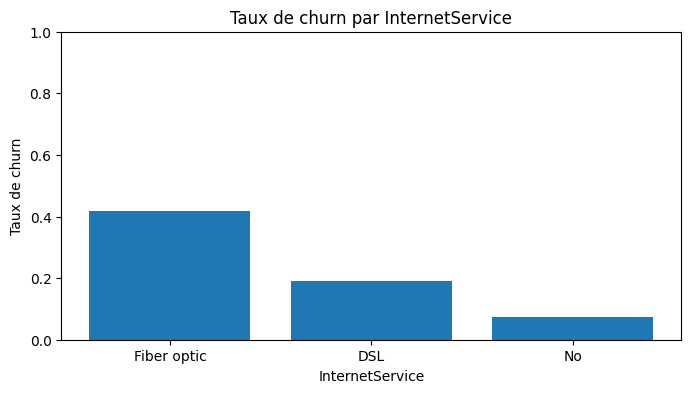

,n_clients,churn_rate
InternetService,,
Fiber optic,3096,0.418928
DSL,2416,0.189983
No,1520,0.074342


In [12]:
plot_churn_rate(df, "OnlineSecurity")
plot_churn_rate(df, "TechSupport")
plot_churn_rate(df, "InternetService")

On remarque que les clients sans sécurité en ligne ou support technique ont plus tendance à churn, ceci peut refléter un besoin des clients vis à vis de ces éléments pouvant apporter un attachement client. On observe aussi un taux de churn plus élevé sur des services internet plus qualitatif, ceci montre un point sous jacent, soit le prix est trop élevé d'après le client, soit l'offre de fibre est plus récente et donc les clients qui en bénéficient le sont aussi, soit les attentes des clients sont plus élevées ou encore le profil des clients qui est différent. 

In [13]:
pd.crosstab(df["InternetService"], df["Contract"], normalize="index")

Contract,Month-to-month,One year,Two year
InternetService,,,
DSL,0.506209,0.235927,0.257864
Fiber optic,0.687339,0.174096,0.138566
No,0.344737,0.238816,0.416447


In [14]:
df.groupby(["InternetService","Contract"])["Churn"].mean()

InternetService  Contract      
DSL              Month-to-month    0.322159
                 One year          0.092982
                 Two year          0.019262
Fiber optic      Month-to-month    0.546053
                 One year          0.192950
                 Two year          0.072261
No               Month-to-month    0.188931
                 One year          0.024793
                 Two year          0.007899
Name: Churn, dtype: float64

Nous observons en effet que ceci est sûrement dû aux contrats qui sont plus récent que les autres.

# Analyse des variables démographiques

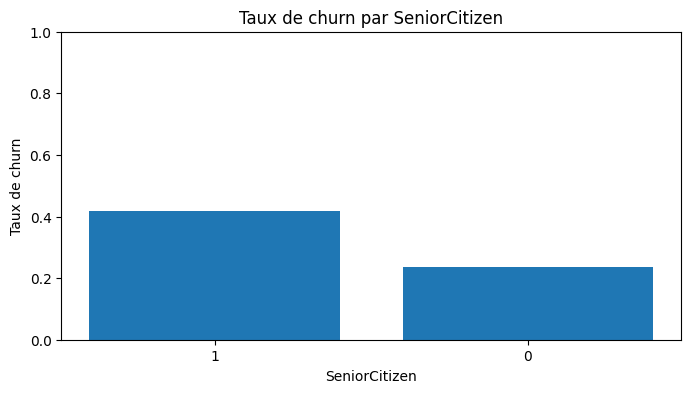

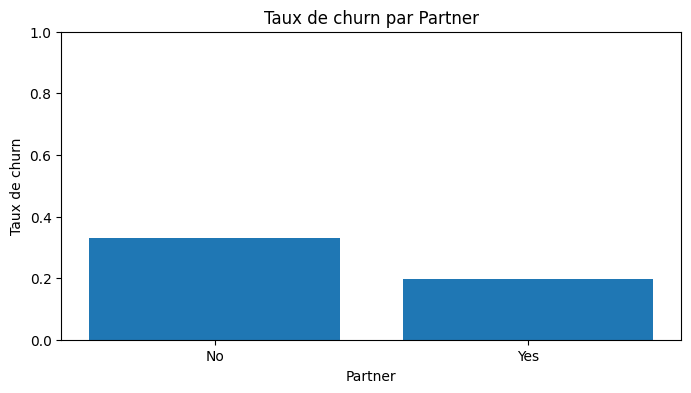

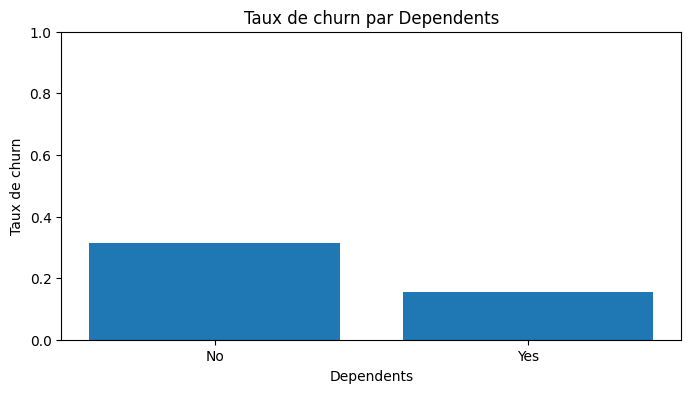

,n_clients,churn_rate
Dependents,,
No,4933,0.312791
Yes,2099,0.155312


In [15]:
plot_churn_rate(df, "SeniorCitizen")
plot_churn_rate(df, "Partner")
plot_churn_rate(df, "Dependents")

Les clients sans dépendances ou qui ne sont pas partenaires churn d'avantage. La variable sur les senior est à interprêter prudement mais il semble que les senior ont plus tendance à churn.

# Croisement du contrat avec son ancienneté

In [16]:
cross_summary = (
    df.groupby(["Contract", "tenure_group"])["Churn"]
    .mean()
    .unstack()
)

cross_summary

C:\Users\QuentinGENSE\AppData\Local\Temp\ipykernel_25456\4039398083.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(["Contract", "tenure_group"])["Churn"]


tenure_group,0-12 mois,13-24 mois,25-48 mois,49-72 mois
Contract,,,,
Month-to-month,0.513541,0.377205,0.329177,0.260234
One year,0.105691,0.081218,0.106178,0.129338
Two year,0.000000,0.000000,0.021898,0.033254


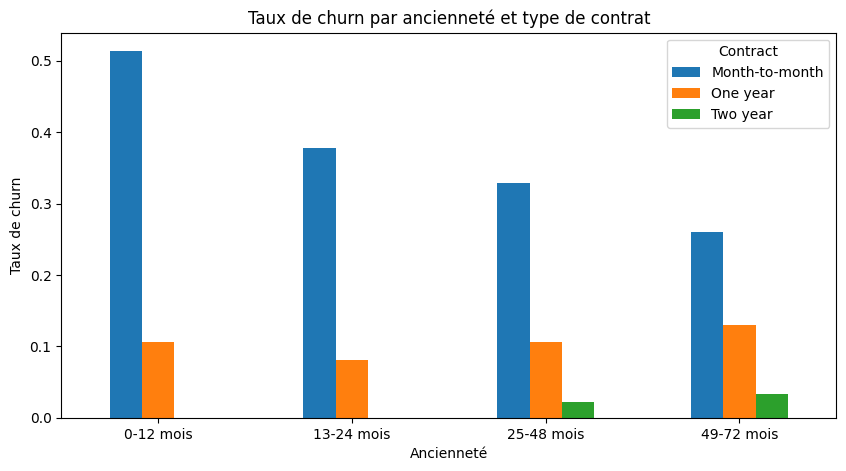

In [17]:
cross_summary.T.plot(kind="bar", figsize=(10, 5))
plt.title("Taux de churn par ancienneté et type de contrat")
plt.xlabel("Ancienneté")
plt.ylabel("Taux de churn")
plt.xticks(rotation=0)
plt.legend(title="Contract")
plt.show()

On observe sur ce graphique que le taux de churn des contrats au mois ont tendances à baisser avec leur ancienneté contrairement aux contrats à l'année ou encore de deux an qui eux augmente avec le temps. Néanmoins le risque maximal se situe tout de même lors de la première année du contrat de manière globale. 

# Tableau de synthèse business

In [18]:
eda_summary = {
    "churn_global": df["Churn"].mean(),
    "month_to_month_churn": df[df["Contract"] == "Month-to-month"]["Churn"].mean(),
    "two_year_churn": df[df["Contract"] == "Two year"]["Churn"].mean(),
    "new_clients_churn": df[df["tenure"] <= 12]["Churn"].mean(),
    "high_monthly_churn": df[df["monthlycharges_group"] == "Q4 - élevé"]["Churn"].mean(),
    "no_techsupport_churn": df[df["TechSupport"] == "No"]["Churn"].mean()
}

pd.Series(eda_summary)

churn_global            0.265785
month_to_month_churn    0.427097
two_year_churn          0.028487
new_clients_churn       0.476782
high_monthly_churn      0.328783
no_techsupport_churn    0.416475
dtype: float64

En comparant les secteurs on remarque que le secteur le plus risqué se situe sur les nouveaux clients suivit de près par les contrats au mois.

# Résumé + Conclusion

1. Les clients en contrat month-to-month présentent le risque de churn le plus élevé.
2. Le churn est particulièrement fort chez les clients récents, surtout durant les 12 premiers mois.
3. Les clients avec des mensualités élevées semblent davantage exposés au churn.
4. L’absence de services comme TechSupport ou OnlineSecurity est associée à un churn plus élevé.
5. Le segment prioritaire de rétention regroupe les clients récents, en contrat mensuel, avec peu de services additionnels.

# Sauvegarder le dataset enrichi

In [19]:
df.to_csv("../data/processed/eda_telco_churn.csv", index=False)